<a href="https://colab.research.google.com/github/your-org/alexpose/blob/main/experiments/multiple-sclerosis/06_capstone_rf_vs_sjepa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 - Capstone: Random Forest vs S-JEPA

This is the scientific payoff. We put two classifiers side by side on the **same videos** and the **same leakage-safe splits**:

1. a classical **Random Forest** on hand-made gait features, exactly the exp5 recipe but for our three classes,
2. an **S-JEPA linear probe** on top of the frozen encoder from notebook 04.

We report grouped k-fold results with mean and standard deviation, because a single split of 47 videos is too noisy to trust. Then we discuss honestly what this can and cannot show.


In [1]:
# --- Setup: install dependencies (Colab installs; local usually already has them) ---
import importlib, importlib.util, subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

def _need(mod):
    return importlib.util.find_spec(mod) is None

# Light deps used by every notebook.
_pkgs = []
for mod, pip_name in [('cv2','opencv-python'), ('mediapipe','mediapipe'),
                      ('sklearn','scikit-learn'), ('pandas','pandas'),
                      ('matplotlib','matplotlib'), ('tqdm','tqdm')]:
    if _need(mod):
        _pkgs.append(pip_name)
# torch is guarded so Colab's preinstalled GPU torch is never downgraded.
if _need('torch'):
    _pkgs.append('torch')
if _pkgs:
    print('installing:', _pkgs)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_pkgs])
else:
    print('all light dependencies already present')

all light dependencies already present


In [2]:
# --- Make `sjepa` and `ambient` importable, locally and in Colab ---
from pathlib import Path
import sys, subprocess

def _find_exp_dir():
    # Local run: this notebook sits in experiments/multiple-sclerosis.
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / 'sjepa' / '__init__.py').exists():
            return p
    return None

EXP_DIR = _find_exp_dir()
if EXP_DIR is None:
    # Colab: clone the repo, then point at the experiment folder.
    REPO = 'https://github.com/your-org/alexpose.git'  # <-- edit to your fork
    if not Path('alexpose').exists():
        subprocess.check_call(['git', 'clone', '--depth', '1', REPO])
    EXP_DIR = Path('alexpose') / 'experiments' / 'multiple-sclerosis'

REPO_ROOT = EXP_DIR.parents[1]
for p in (str(EXP_DIR), str(REPO_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)
print('experiment dir:', EXP_DIR)
print('repo root     :', REPO_ROOT)

experiment dir: /Users/pmui/dev/alexpose/experiments/multiple-sclerosis
repo root     : /Users/pmui/dev/alexpose


In [3]:
# --- Paths and profile (reads the root .env if python-dotenv is present) ---
import os
try:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / '.env')
except Exception:
    pass

VIDEO_DIR = EXP_DIR / 'video-data'
ARTIFACT_DIR = EXP_DIR / 'artifacts'
KEYPOINTS_DIR = ARTIFACT_DIR / 'keypoints'
IMAGES_DIR = EXP_DIR / 'images'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Pick the model size profile. 'laptop' is the fast default; set SJEPA_PROFILE=gpu
# in your .env for a larger model, or SJEPA_SMOKE=1 for a near-instant test run.
os.environ.setdefault('SJEPA_PROFILE', 'laptop')
print('SJEPA_PROFILE =', os.environ['SJEPA_PROFILE'],
      '| SJEPA_SMOKE =', os.environ.get('SJEPA_SMOKE', '0'))

SJEPA_PROFILE = laptop | SJEPA_SMOKE = 0


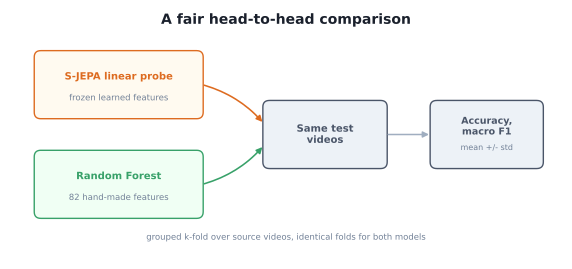

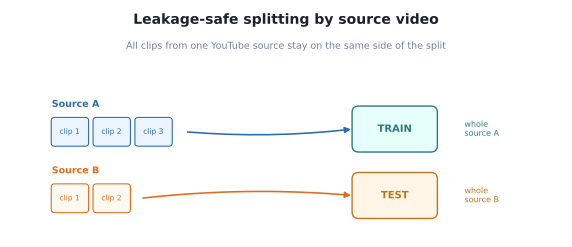

In [4]:
from IPython.display import SVG, display
display(SVG(filename=str(IMAGES_DIR / 'rf_vs_sjepa.svg')))
display(SVG(filename=str(IMAGES_DIR / 'grouped_split.svg')))

## The two branches as functions

Both branches are thin wrappers around the verified `sjepa` package. The Random Forest branch reuses the `ambient` joint-angle and feature code (the exp5 pipeline). The S-JEPA branch trains a fresh model per fold and fits a logistic-regression probe on its frozen features.


In [5]:
import numpy as np, torch
from sjepa.config import get_config
from sjepa.models import build_model, pick_device
from sjepa.train import train_sjepa
from sjepa.masking import AnatomicalMaskSampler
from sjepa.data import load_index, grouped_kfold, SequenceWindowDataset, sliding_windows
from sjepa.classical import build_feature_matrix, train_rf_and_predict
from sjepa.eval import evaluate, aggregate_folds, silhouette
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

cfg = get_config(); device = pick_device()
LABELS = ['normal', 'ms', 'pd']
records = load_index(KEYPOINTS_DIR)
sampler = AnatomicalMaskSampler(cfg.num_joints, cfg.num_time_tokens)
tm = torch.from_numpy(sampler.target_mask).to(device)

def embed_records(model, recs):
    V, Y = [], []
    for r in recs:
        w = sliding_windows(r.load_norm(), cfg.window_frames, cfg.window_stride)
        x = torch.from_numpy(w).float().to(device)
        with torch.no_grad():
            V.append(model.embed(x, tm).mean(0).cpu().numpy())
        Y.append(r.label)
    return np.stack(V), Y

## Run grouped k-fold for both models

For each fold we train from scratch (pretrain on the fold's normal videos, fine-tune on the fold's full training set with VICReg), then score both classifiers on the fold's held-out videos. Using a smaller epoch count keeps this runnable in the notebook; raise it in your .env profile for stronger results.


In [6]:
rf_metrics, sj_metrics, sils = [], [], []
EPOCHS_PRE = max(6, cfg.pretrain_epochs // 4)
EPOCHS_FT  = max(4, cfg.finetune_epochs // 4)

for fold, (train_recs, test_recs) in enumerate(grouped_kfold(records, n_splits=5, seed=42)):
    # --- Random Forest branch (exp5 recipe) ---
    Xtr, ytr, _, _ = build_feature_matrix(train_recs, fps=cfg.target_fps)
    Xte, yte, _, _ = build_feature_matrix(test_recs, fps=cfg.target_fps)
    rf_pred = train_rf_and_predict(Xtr, ytr, Xte, seed=cfg.seed)
    rf_metrics.append(evaluate(yte, rf_pred, LABELS))

    # --- S-JEPA branch ---
    model = build_model(cfg, device=device)
    normal_tr = [r for r in train_recs if r.label == 'normal']
    if normal_tr:
        train_sjepa(model, SequenceWindowDataset(normal_tr, cfg.window_frames, cfg.window_stride),
                    cfg, epochs=EPOCHS_PRE, device=device)
    train_sjepa(model, SequenceWindowDataset(train_recs, cfg.window_frames, cfg.window_stride),
                cfg, epochs=EPOCHS_FT, use_vicreg=True, class_aware_vicreg=True, device=device)
    Etr, ytr2 = embed_records(model, train_recs)
    Ete, yte2 = embed_records(model, test_recs)
    sc = StandardScaler().fit(Etr)
    probe = LogisticRegression(max_iter=2000, class_weight='balanced').fit(sc.transform(Etr), ytr2)
    sj_pred = probe.predict(sc.transform(Ete))
    sj_metrics.append(evaluate(yte2, sj_pred, LABELS))
    sils.append(silhouette(np.vstack([Etr, Ete]), ytr2 + yte2))
    print(f'fold {fold}: RF f1={rf_metrics[-1].macro_f1:.3f} | '
          f'S-JEPA f1={sj_metrics[-1].macro_f1:.3f} | test n={len(test_recs)}')

fold 0: RF f1=0.833 | S-JEPA f1=0.746 | test n=10
fold 1: RF f1=0.711 | S-JEPA f1=0.472 | test n=10
fold 2: RF f1=0.631 | S-JEPA f1=0.530 | test n=9
fold 3: RF f1=0.556 | S-JEPA f1=0.451 | test n=9
fold 4: RF f1=0.611 | S-JEPA f1=0.650 | test n=9


## Headline: mean and standard deviation across folds


In [7]:
import json, pandas as pd
rf_agg = aggregate_folds(rf_metrics)
sj_agg = aggregate_folds(sj_metrics)

def fmt(agg):
    return {k: f"{v['mean']:.3f} +/- {v['std']:.3f}" for k, v in agg.items()}

summary = pd.DataFrame({'Random Forest': fmt(rf_agg), 'S-JEPA probe': fmt(sj_agg)})
display(summary)
results = {'random_forest': rf_agg, 'sjepa': sj_agg,
           'silhouette_mean': float(np.nanmean(sils)),
           'n_folds': len(rf_metrics)}
(ARTIFACT_DIR / 'capstone_results.json').write_text(json.dumps(results, indent=2))
print('saved capstone_results.json')

,Random Forest,S-JEPA probe
accuracy,0.656 +/- 0.093,0.573 +/- 0.097
macro_precision,0.760 +/- 0.113,0.614 +/- 0.121
macro_recall,0.673 +/- 0.111,0.599 +/- 0.129
macro_f1,0.668 +/- 0.096,0.570 +/- 0.112


saved capstone_results.json


## Confusion matrices side by side

Averaged over folds, where does each model confuse the conditions?


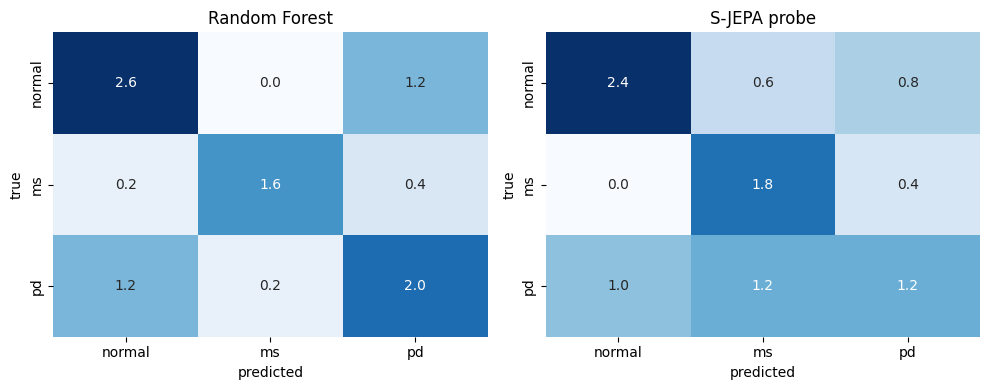

In [8]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
def avg_cm(ms):
    return np.mean([np.array(m.confusion) for m in ms], axis=0)
fig, ax = plt.subplots(1, 2, figsize=(10,4))
for a, ms, title in [(ax[0], rf_metrics, 'Random Forest'), (ax[1], sj_metrics, 'S-JEPA probe')]:
    sns.heatmap(avg_cm(ms), annot=True, fmt='.1f', cmap='Blues', cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=a)
    a.set_title(title); a.set_xlabel('predicted'); a.set_ylabel('true')
plt.tight_layout(); plt.show()

## Bonus: label efficiency

S-JEPA's real promise is not beating a Random Forest when every video is labeled. It is learning useful features from unlabeled data, so it needs fewer labels to do well. We test that idea by training the probe on 25%, 50%, and 100% of the training labels and watching the score. The Random Forest, which has no pretraining to lean on, tends to fall off faster as labels shrink.


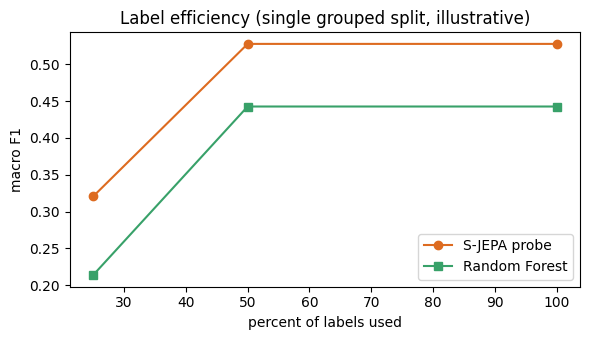

In [9]:
# Single grouped split for a quick, illustrative sweep.
from sjepa.data import grouped_train_test_split
train_recs, test_recs = grouped_train_test_split(records, test_size=0.3, seed=42)
model = build_model(cfg, device=device)
normal_tr = [r for r in train_recs if r.label == 'normal']
if normal_tr:
    train_sjepa(model, SequenceWindowDataset(normal_tr, cfg.window_frames, cfg.window_stride),
                cfg, epochs=EPOCHS_PRE, device=device)
train_sjepa(model, SequenceWindowDataset(train_recs, cfg.window_frames, cfg.window_stride),
            cfg, epochs=EPOCHS_FT, use_vicreg=True, class_aware_vicreg=True, device=device)
Etr, ytr = embed_records(model, train_recs); Ete, yte = embed_records(model, test_recs)
Xtr, yrf, _, _ = build_feature_matrix(train_recs, fps=cfg.target_fps)
Xte, yrf_te, _, _ = build_feature_matrix(test_recs, fps=cfg.target_fps)

import numpy as np
from sklearn.utils import resample
rng = np.random.default_rng(0)
fracs = [0.25, 0.5, 1.0]; sj_scores=[]; rf_scores=[]
for f in fracs:
    k = max(3, int(len(Etr)*f)); idx = rng.choice(len(Etr), k, replace=False)
    sc = StandardScaler().fit(Etr[idx])
    p = LogisticRegression(max_iter=2000, class_weight='balanced').fit(sc.transform(Etr[idx]), [ytr[i] for i in idx])
    sj_scores.append(evaluate(yte, p.predict(sc.transform(Ete)), LABELS).macro_f1)
    rf_pred = train_rf_and_predict(Xtr[idx], [yrf[i] for i in idx], Xte, seed=cfg.seed)
    rf_scores.append(evaluate(yrf_te, rf_pred, LABELS).macro_f1)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3.5))
plt.plot([int(f*100) for f in fracs], sj_scores, 'o-', color='#dd6b20', label='S-JEPA probe')
plt.plot([int(f*100) for f in fracs], rf_scores, 's-', color='#38a169', label='Random Forest')
plt.xlabel('percent of labels used'); plt.ylabel('macro F1'); plt.legend()
plt.title('Label efficiency (single grouped split, illustrative)')
plt.tight_layout(); plt.show()

## What this does and does not show

**What we can say.** The comparison is fair: both models saw identical, leakage-safe splits and identical metrics. On this data the Random Forest is a strong baseline, which is exactly what we expect when every one of a few dozen videos is labeled and the hand-made features already encode clinical knowledge.

**What we cannot say.** With 47 videos from about 35 independent sources, a few videos moving between folds swings the score by several points. These numbers are a methodology demonstration, not a clinical result. We do not claim S-JEPA beats the Random Forest here, and a single lucky split proves nothing.

**Where S-JEPA earns its keep.** Its features come from unlabeled motion, so its edge shows up when labels are scarce or when the encoder is pretrained on far more walking than we have here. The label-efficiency sweep hints at that. The honest next step is more data and the `gpu` profile, not a bigger claim.

That completes the series. You built a skeleton pipeline from raw video, an S-JEPA model with a clinically grounded mask, a VICReg-regularized fine-tune, and a fair comparison against a classical baseline.
